# Authors
- Raphael Wäspi (18-918-938)
- Nicolas Huber (16-936-205)

In [207]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import os
import glob
import re
import random
from statistics import mean 
from tqdm import tqdm
import shutil

In [208]:
# Define colors with reduced opacity from a colormap
COLOR_BLUE = 'dodgerblue'
COLOR_RED = 'lightcoral'
COLOR_GREY = 'slategrey'

# Define the main data directory
OUTPUT_PATH = "./output"

In [209]:
# Prepare output folder

# Delete the entire 'output' directory and its contents
if os.path.exists(OUTPUT_PATH):
    shutil.rmtree(OUTPUT_PATH)

# Create the 'output' directory
os.makedirs(OUTPUT_PATH)

# Define subdirectories
OUTPUT_PATH_ER = os.path.join(OUTPUT_PATH, "erdos_renyi_avg_clustering")

# Recreate the subdirectories
os.makedirs(OUTPUT_PATH_ER)

In [210]:
# Define the directory containing the .gml files
directory = 'assignment_02_data'

# Use glob to get a list of all .gml files in the directory
gml_files = glob.glob(os.path.join(directory, '*.gml'))

# Init an empty dictionary for all graphs - the key is the actual name, and the value is the graph data
graphs = {}

# Use tqdm to show a progress bar in Jupyter Notebook
with tqdm(total=len(gml_files), desc="Loading GML Files") as pbar:
    # Loop through the list of .gml files and load them
    for file_path in gml_files:
        with open(file_path, 'r') as file:
            content = file.read()
            
            # Use regex to extract the desired part
            match = re.search(r'/([^/]+)\.gml$', file_path)
            if match:
                graph_name = match.group(1)
                
                # Add to the graph dictionary
                graph = nx.read_gml(file_path)
                graphs[graph_name] = graph
                
                # Print the graph name when each part is finished
                print(f"Finished loading {graph_name}")
                
        pbar.update(1)  # Update the progress bar

Loading GML Files:  43%|████▎     | 3/7 [00:07<00:08,  2.02s/it]

Finished loading graph_internet
Finished loading graph_Korea
Finished loading graph_eu_airlines
Finished loading graph_macaque


Loading GML Files: 100%|██████████| 7/7 [00:21<00:00,  3.14s/it]

Finished loading graph_hep-th
Finished loading graph_starwars
Finished loading graph_madrid


# I Erdos-Renyi Model

In [211]:
graphs

{'graph_internet': <networkx.classes.graph.Graph at 0x13672ffd0>,
 'graph_Korea': <networkx.classes.graph.Graph at 0x134b5ec50>,
 'graph_eu_airlines': <networkx.classes.graph.Graph at 0x139edef10>,
 'graph_macaque': <networkx.classes.graph.Graph at 0x13a5feb50>,
 'graph_hep-th': <networkx.classes.graph.Graph at 0x145323f90>,
 'graph_starwars': <networkx.classes.graph.Graph at 0x1348164d0>,
 'graph_madrid': <networkx.classes.graph.Graph at 0x13aa57290>}

## 1. Write a function to generate an Erdős-Rényi undirected graph G(N, p).
It should take in two input parameters:
- N: the number of nodes of the network,
- p: the probability of an edge existing between two nodes,

and it should output a network (the data structure to represent the network is left to your choice, in the
hint a suggestion is provided).

In [212]:
random.seed(a=42)

In [213]:
def generate_custom_erdos_renyi_graph(N, p):
    # Precondition
    if p < 0 or p > 1:
        raise ValueError("Probability p must be in the range [0, 1]")
    

    # Create a graph object
    G = nx.Graph()
    
    # Init N nodes 
    G.add_nodes_from(range(N))

    # Model: each pair of 𝑁 nodes is connected with edge creation probability 𝑝
    for i in range(N):
        for j in range(i + 1, N):
            # In total: N (N-1) * 0.5 possible links
            if random.random() < p: # Select node with probability p
                G.add_edge(i, j)

    return G

## 2. Using the function you wrote at point (1), generate three Erdős-Rényi networks with N = 100 nodes and link probability 
- (a) p = 0.001,
- (b) p = 0.01,
- (c) p = 0.1, and
- (d) p = 0.5.

Provide a visualisation of these networks, in order to emphasize the existence of connected components.

In [214]:
SEED = 42
N = 100
PROBABILITIES = [0.001, 0.01, 0.1, 0.5]

In [215]:
generated_networks = []

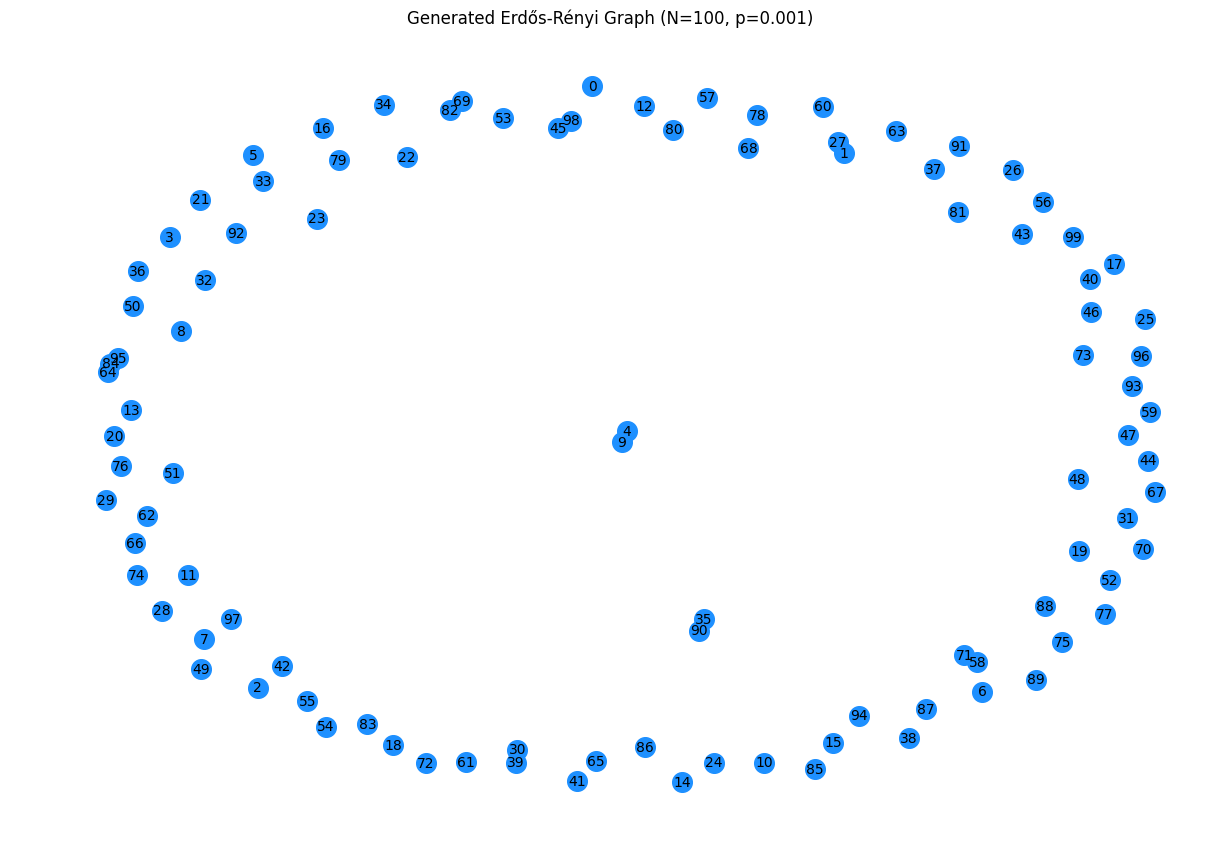

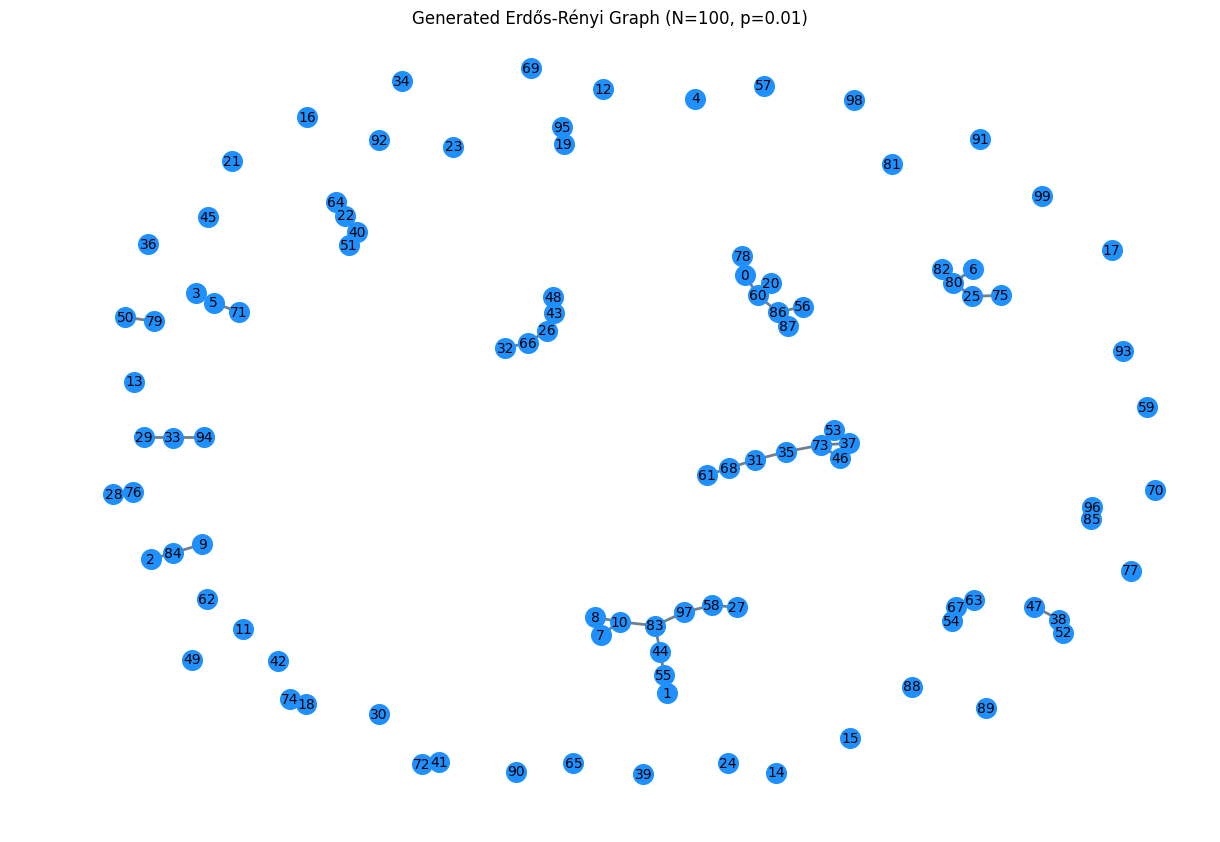

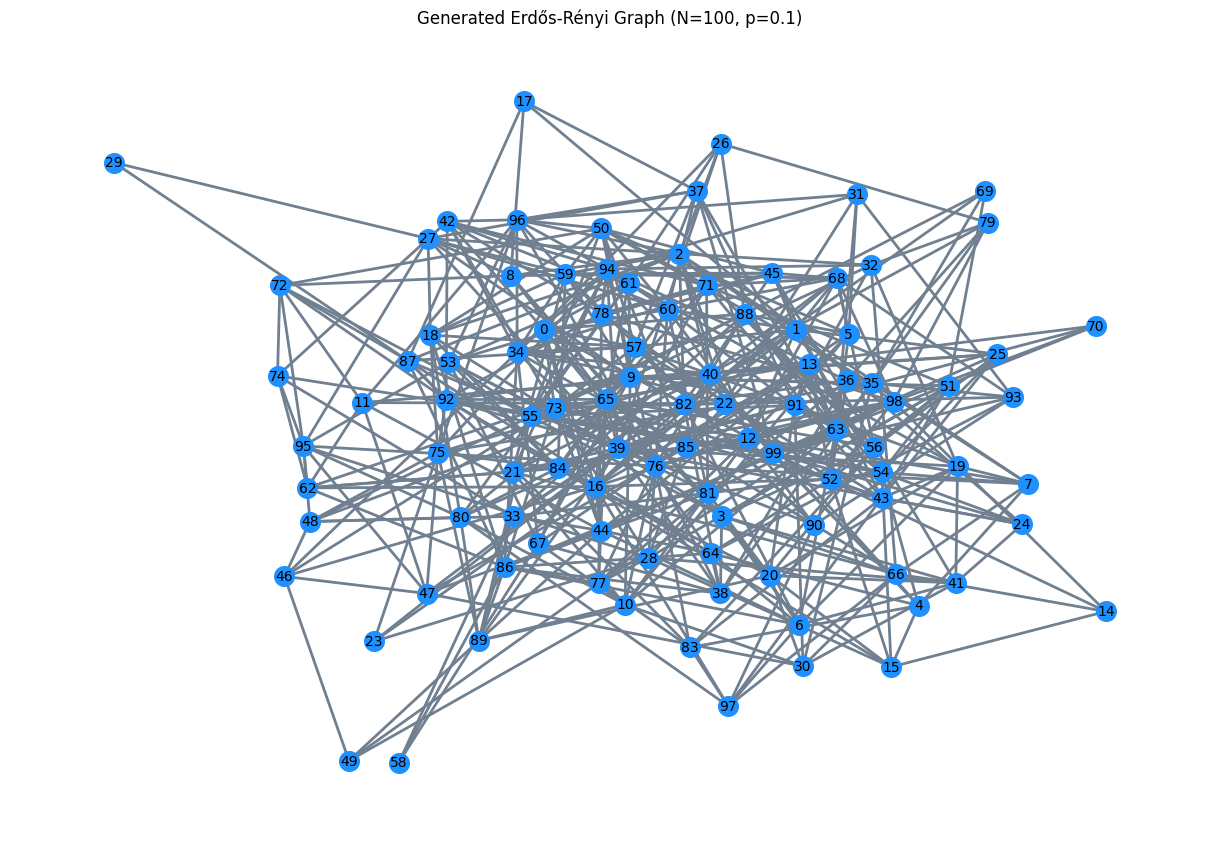

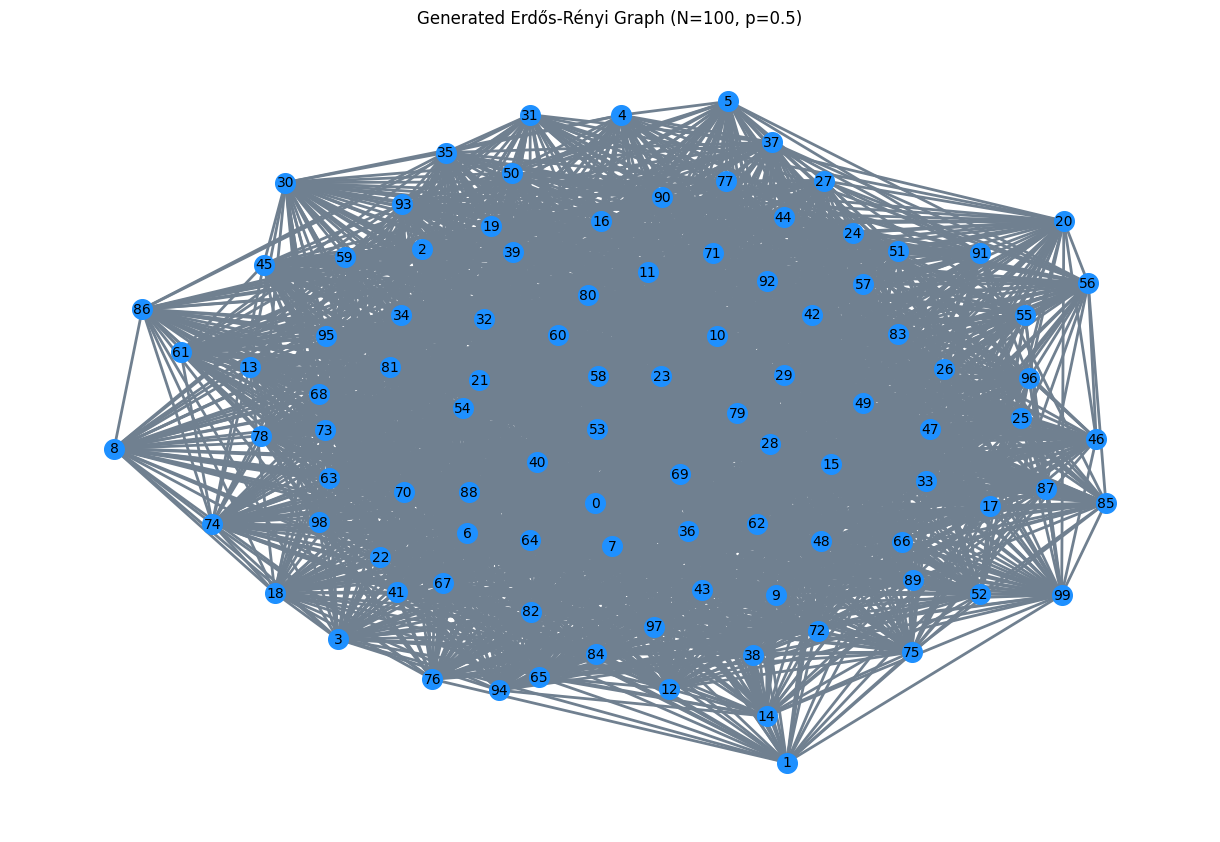

In [216]:
for p in PROBABILITIES:
    g = generate_custom_erdos_renyi_graph(N, p)
    generated_networks.append({"graph":g, "N": N, "p": p})
    pos = nx.spring_layout(G=g, seed=SEED)  # Layout algorithm for node positions
    plt.figure(figsize=(12, 8))
    nx.draw(g, pos, with_labels=True, node_size=200, node_color=COLOR_BLUE, edge_color=COLOR_GREY, width=2, font_size=10)
    plt.title(f"Generated Erdős-Rényi Graph (N={N}, p={p})")
    plt.axis('off')
    
    
    file_name = f"sample_network_N{N}_p{p}.png"
    complete_plot_filename = os.path.join(OUTPUT_PATH_ER, file_name)
    plt.savefig(complete_plot_filename)
    plt.show()

## 3. Generate ER graphs with N = 100 nodes for different edge creation probabilities p ∈ [0, 1] and plot the probability that a node belongs to the largest connected component NG/N as a function of p and mark with a vertical line the critical probability pC = 1/N.

In [217]:
N = 100
sample_size = 100
probabilities_log_range = np.logspace(np.log(1e-3),np.log(0.5),200)

In [218]:
ratios_avg = {}
for p in probabilities_log_range:
    ratios = []
    
    for n in range(sample_size):
        # Generate ER graph samples for each p
        g = generate_custom_erdos_renyi_graph(N,p)
        
        # Get all components
        # https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.components.connected_components.html
        connected_components = sorted(nx.connected_components(g), key=len, reverse=True)
        
        # Get largest connected component (LCC)
        largest_connected_component = g.subgraph(connected_components[0])
        
        # Find size of lcc
        nodes_lcc = largest_connected_component.number_of_nodes()
        
        # Calculate ration N_G / N
        ratio = float(nodes_lcc / len(g))
        
        # Append to ratio sample list
        ratios.append(ratio)
    
    # Average all results in ratios to get value for a specific p
    ratios_avg[f"{p}"] = mean(ratios)

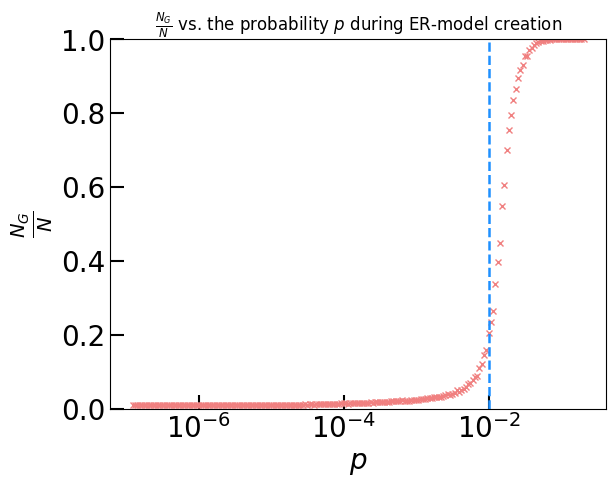

In [219]:
fig = plt.figure()
ax = fig.add_subplot(111)

ax.plot(probabilities_log_range, ratios_avg.values(), "x",  ms=5,color=COLOR_RED, label=r"$N_G / N$") # Regular values
plt.axvline(x=1./(N-1),linestyle="--", lw="1.8",color=COLOR_BLUE) # Horizontal line p_c = 1 / N

# Formatting
plt.title(r"$\frac{N_G}{N}$ vs. the probability $p$ during ER-model creation")
ax.set_xlabel(r"$p$", fontsize=20)
ax.set_ylabel(r"$\frac{N_G}{N}$", fontsize=20)
ax.tick_params(which = "major", axis='both', width=1.5, length = 10, labelsize=20,direction="in")
ax.tick_params(which = "minor", axis='both', width=1.5, length = 5, labelsize=20,direction="in")
plt.yticks(fontsize = 20)
plt.xticks(fontsize = 20)
ax.set_ylim(0,1.0)
ax.set_xscale("log")

file_name = "average_ng_vs_n_ratio_for_different_probabilities.png"
complete_plot_filename = os.path.join(OUTPUT_PATH_ER, file_name)
plt.savefig(complete_plot_filename)
plt.show()


## 4. Plot the average clustering ⟨c⟩ as a function of p and give an interpretation of the result.

In [220]:
#average clustering
probabilities_log_range_cluster = np.arange(0.1,1.1,0.1) # x-Axis
clusters = []
for p in probabilities_log_range_cluster:
    g = generate_custom_erdos_renyi_graph(N=N,p=p)
    # Calculate average clustering
    # https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.cluster.average_clustering.html
    clus = nx.average_clustering(g)
    clusters.append(clus)

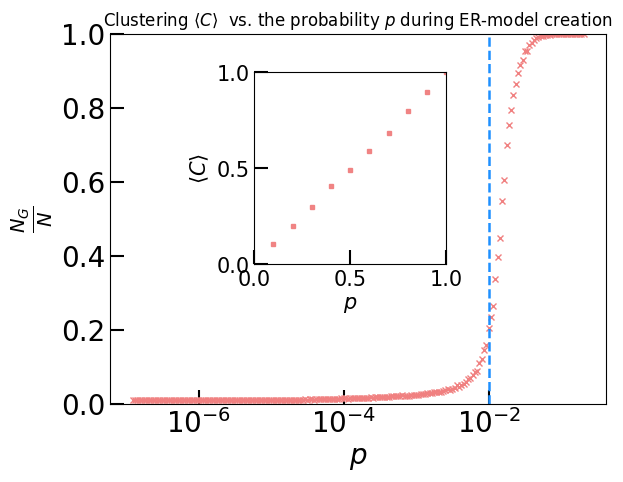

In [221]:
fig = plt.figure()
ax = fig.add_subplot(111)

ax.plot(probabilities_log_range, ratios_avg.values(), "x",  ms=5,color=COLOR_RED, label=r"$N_G / N$") # Regular values
plt.axvline(x=1./(N-1),linestyle="--", lw="1.8",color=COLOR_BLUE) # Horizontal line p_c = 1 / N

# Formatting
plt.title(r"Clustering $\langle C \rangle$  vs. the probability $p$ during ER-model creation")
ax.set_xlabel(r"$p$", fontsize=20)
ax.set_ylabel(r"$\frac{N_G}{N}$", fontsize=20)
ax.tick_params(which = "major", axis='both', width=1.5, length = 10, labelsize=20,direction="in")
ax.tick_params(which = "minor", axis='both', width=1.5, length = 5, labelsize=20,direction="in")
plt.yticks(fontsize = 20)
plt.xticks(fontsize = 20)
ax.set_ylim(0,1.0)
ax.set_xscale("log")

# Formatting
left, bottom, width, height = [0.30,0.40,0.40,0.40]
axinset = fig.add_axes([left, bottom, width, height])
axinset.plot(probabilities_log_range_cluster,clusters, 's', ms=3, c=COLOR_RED, alpha=0.95, label=r"$v(t)$")
axinset.tick_params(axis="both", width=1.5, length = 10, labelsize=15, direction="in")
axinset.set_xticks([0.,.5,1.])
axinset.set_yticks([0.,.5,1.])
axinset.set_xlim(0.,1.)
axinset.set_ylim(0.,1.)
axinset.set_aspect("equal")
axinset.set_xlabel(r"$p$", fontsize=15)
axinset.set_ylabel(r"$\langle C \rangle$", fontsize=15)

file_name = "average_clustering_for_different_probabilities.png"
complete_plot_filename = os.path.join(OUTPUT_PATH_ER, file_name)
plt.savefig(complete_plot_filename)
plt.show()